In [105]:
import torch
import numpy as np
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.optim as optim

In [106]:
op = torch.rand(64,64,16 ,dtype = torch.cfloat)
print(op[0,0,0])

tensor(0.3897+0.2086j)


In [ ]:
n_train = 100 # number of training samples

# Load the data
# - AC_data_input.npy
# - AC_data_output.npy

# We will decrease the resolution to s = 256, for more convenient training

x_data = torch.from_numpy(np.load("datasets/AC_data_input.npy")).type(torch.float32)
y_data = torch.from_numpy(np.load("datasets/AC_data_output.npy")).type(torch.float32)

x_data = x_data.permute(0,2,1)
y_data = y_data.unsqueeze(1)
s = 512
x_data = F.interpolate(x_data.unsqueeze(2), size = (1, s), mode = "bicubic")[:,:,0]
y_data = F.interpolate(y_data.unsqueeze(2), size = (1, s), mode = "bicubic")[:,:,0]


input_function_train = x_data[:n_train, :]
output_function_train = y_data[:n_train, :]
input_function_test = x_data[n_train:, :]
output_function_test = y_data[n_train:, :]

batch_size = 10

training_set = DataLoader(TensorDataset(input_function_train, output_function_train), batch_size=batch_size, shuffle=True)
testing_set = DataLoader(TensorDataset(input_function_test, output_function_test), batch_size=batch_size, shuffle=False)

In [117]:
n_train= 300

x_data = torch.from_numpy(np.load('datasets/AC_data_input.npy'))
y_data = torch.from_numpy(np.load('datasets/AC_data_output.npy'))

print(x_data.shape)# [batch_size, size, channles]


x_data = x_data.permute(0,2,1)          # [batch_size, channles, size]
y_data = y_data.unsqueeze(1)
s = 512                           # since only 3 layers are used and divided till 8 in CNO block we restrict the size to 256
x_data = F.interpolate(x_data.unsqueeze(2), size = (1, s), mode = "bicubic")[:,:,0]
y_data = F.interpolate(y_data.unsqueeze(2), size = (1, s), mode = "bicubic")[:,:,0]

print(x_data.shape)

x_train = x_data[:n_train, :, :]
x_test = x_data[n_train:, :, :]
y_train = y_data[:n_train, :]
y_test = y_data[n_train:, :]
print(y_test.shape)

batch_size = 10

training_set = DataLoader(TensorDataset(input_function_train, output_function_train), batch_size=batch_size, shuffle=True)
testing_set = DataLoader(TensorDataset(input_function_test, output_function_test), batch_size=batch_size, shuffle=False)

torch.Size([1000, 1001, 2])
torch.Size([1000, 2, 512])
torch.Size([700, 1, 512])


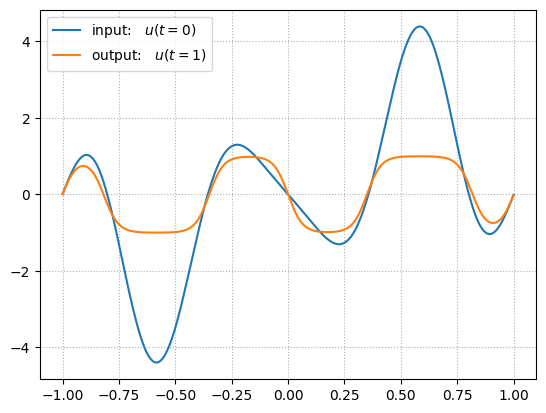

In [118]:
#view data

index = 180

plt.plot(np.linspace(-1,1, x_data.shape[2]),x_data[index, 1, :], label = 'input:   $u(t = 0)$')
plt.plot(np.linspace(-1,1, y_data.shape[2]),y_data[index, 0,:], label = 'output:   $u(t = 1)$')
plt.grid(ls=":")
plt.legend()

In [119]:
# class for ativation function, we need to increase the frequency and then add activation funvtion

class CON_ReLu(nn.Module):
    def __init__(self, input_size, output_size):
        super().__init__()
        self.insize = input_size
        self.outsize = output_size
        self.act = nn.ReLU()
    def forward(self,x):
        out = F.interpolate(x.unsqueeze(2), size = (1,2* self.insize),mode='bicubic', antialias= True) # interpolating frequencies to high number of frequencies
        out = self.act(out)
        out = F.interpolate(out, size=(1, self.outsize), mode='bicubic', antialias= True)#interpolating frequencies to original number of frequencies in output
        return out.squeeze(2)
        

    


In [120]:
# backboone of the classes projection, cno and residual calculation

#1. lift and projection class we change the dimentions of channels only
class Lift_Projection(nn.Module):
    def __init__(self, in_channels, out_channels, in_size):
        super().__init__()
        temp_con = 32              # we lift the channel to this usinf Con and we apply Con1d
        self.conv_1 = CNO(in_channels, temp_con, in_size, in_size)
        self.convolution = nn.Conv1d(temp_con,out_channels, kernel_size=3, padding=1)
    
    def forward(self, x):
        out = self.conv_1(x)
        out = self.convolution(out)
        return out
    

# 2. CNO block, uses custom actiation function. non linearities because  of activation code

class CNO(nn.Module):
    def __init__(self, in_channels, out_channels, in_size, out_size):
        super().__init__()
        self.convolution = nn.Conv1d(in_channels, out_channels, kernel_size=3 , padding=1)
        self.batchNorm = nn.BatchNorm1d(out_channels)
        # Change 'in_size' to 'input_size' and 'out_size' to 'output_size'
        self.activation = CON_ReLu(input_size=in_size, output_size=out_size)
    
    def forward(self, x):
        out = self.convolution(x)
        out = self.batchNorm(out)
        out = self.activation(out)
        return out
    
#3. residual calculation class
class residual(nn.Module):
    def __init__(self, channels, size):
        super().__init__() 
        self.conv1 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm1d(channels)
        self.act = CON_ReLu(input_size=size, output_size=size) 
        
        self.conv2 = nn.Conv1d(channels, channels, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm1d(channels)
        
    def forward(self, x):
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.act(out)
        out = self.conv2(out)
        out = self.bn2(out)
        return x + out


In [121]:
# class for CNO, it got CNO block, projection block for lifting and projection and one class for residual calculation
class Model(nn.Module):
    def __init__(self, in_channels, out_channel, in_size):
        # Corrected: standard PyTorch super initialization doesn't take 'self'
        super().__init__()
        
        # Channel configurations: in_channels --> 8 --> 16 --> 32 --> 64
        c_inp, c1, c2, c3, c4 = in_channels, 8, 16, 32, 64

        # Size configurations (e.g., 1000 --> 500 --> 250 --> 125)
        s_inp, s1, s2, s3 = in_size, in_size // 2, in_size // 4, in_size // 8

        # --- Pipeline Stage 1: Data Lifting ---
        self.lift = Lift_Projection(in_channels=c_inp, out_channels=c1,in_size=s_inp)

        # --- Pipeline Stage 2: Encoding Blocks ---
        self.res1_enc = residual(channels=c1, size=s_inp) 
        self.enc1     = CNO(in_channels=c1, out_channels=c2, in_size=s_inp, out_size=s1) 
        
        self.res2_enc = residual(channels=c2, size=s1)
        self.enc2     = CNO(in_channels=c2, out_channels=c3, in_size=s1, out_size=s2)
        
        self.res3_enc = residual(channels=c3, size=s2)
        self.enc3     = CNO(in_channels=c3, out_channels=c4, in_size=s2, out_size=s3)

        # --- Pipeline Stage 3: The Latent Bottleneck Neck ---
        self.res_neck = residual(channels=c4, size=s3)

        # --- Pipeline Stage 4: Scale Mesh Matchers (Crucial for Anti-Aliasing) ---
        # These filter high-frequency noise from the encoder skips right before joining the decoder track.
        self.match_neck = CNO(in_channels=c4, out_channels=c4, in_size=s3, out_size=s3)
        self.match_res3 = CNO(in_channels=c3, out_channels=c3, in_size=s2, out_size=s2)
        self.match_res2 = CNO(in_channels=c2, out_channels=c2, in_size=s1, out_size=s1)
        self.match_res1 = CNO(in_channels=c1, out_channels=c1, in_size=s_inp, out_size=s_inp)

        # --- Pipeline Stage 5: Decoding Blocks (Upsampling Track) ---
        # input channels double due to concatenating skip paths from the encoder stage
        self.dec3 = CNO(in_channels=c4, out_channels=c3, in_size=s3, out_size=s2)             # Up to s2
        self.dec2 = CNO(in_channels=c3 + c3, out_channels=c2, in_size=s2, out_size=s1)        # Up to s1
        self.dec1 = CNO(in_channels=c2 + c2, out_channels=c1, in_size=s1, out_size=s_inp)     # Up to s_inp

        # --- Pipeline Stage 6: Final Output Projection ---
        # Receives decoded track concatenated with the native-resolution skip1 track
        self.project = Lift_Projection(in_channels=c1 + c1, out_channels=out_channel, in_size=s_inp)

    def forward(self, x):
        # 1. Lift spatial domains into initial continuous latent feature space
        x = self.lift(x)                 # State Shape: [Batch, c1, s_inp]
        
        # 2. Forward Encoder Track and save the residual maps for skip connections
        skip1 = self.res1_enc(x)
        x     = self.enc1(skip1)         # Downsamples resolution to s1, channel expands to c2
        
        skip2 = self.res2_enc(x)
        x     = self.enc2(skip2)         # Downsamples resolution to s2, channel expands to c3
        
        skip3 = self.res3_enc(x)
        x     = self.enc3(skip3)         # Downsamples resolution to s3, channel expands to c4
        
        # 3. Process the physical features inside the global bottleneck 
        x = self.res_neck(x)             # State Shape: [Batch, c4, s3]
        
        # 4. Forward Decoder Track, smoothing out data transitions along the way
        x = self.match_neck(x)           # smoothing at enc1, it is done at each layer 
        x = self.dec3(x)                 # Upsamples resolution back to s2, channels drop to c3
        
        # Combine with Encoder context from level 3
        x = torch.cat((x, self.match_res3(skip3)), dim=1)  # Channels: c3 + c3
        x = self.dec2(x)                 # Upsamples resolution back to s1, channels drop to c2
        
        # Combine with Encoder context from level 2
        x = torch.cat((x, self.match_res2(skip2)), dim=1)  # Channels: c2 + c2
        x = self.dec1(x)                 # Upsamples resolution back to s_inp, channels drop to c1
        
        # Combine with Encoder context from level 1 and project down to physical output shape
        x = torch.cat((x, self.match_res1(skip1)), dim=1)  # Channels: c1 + c1
        
        # projection
        output = self.project(x)
        
        return output

In [122]:
learning_rate = 0.001
epochs = 200
step_size = 15
gamma = 0.5

In [123]:
model = Model(in_channels= 2, out_channel=1, in_size=512)
optimizer = optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=1e-8)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
creiterion = nn.MSELoss()

In [124]:
# traing block

for epoch in range (epochs):
    loss_train = 0.0
    for x_train , y_train in training_set:
        optimizer.zero_grad()
        y_pred = model(x_train)
        loss = creiterion(y_pred, y_train)
        loss.backward()
        optimizer.step()
        loss_train += loss.item()
    train_mse = loss_train / len(x_train)
    scheduler.step()
    if epoch % 10 == 0:
        print(loss_train)

5.386320352554321
0.24707784643396735
0.11412670102436095
0.12609519937541336
0.061659378348849714
0.03559418523218483
0.03395207365974784
0.0314696817076765
0.028833311167545617
0.02753340403432958
0.0254269891011063
0.03002256155014038
0.025103110820055008
0.023671182454563677
0.02482670804602094
0.024169124546460807


KeyboardInterrupt: 

In [125]:
with torch.no_grad():
        model.eval()
        test_relative_l2 = 0.0
        for step, (input_batch, output_batch) in enumerate(testing_set):
            output_pred_batch = model(input_batch)
            loss_f = (torch.mean((abs(output_pred_batch - output_batch))) / torch.mean(abs(output_batch))) ** 0.5 * 100
            test_relative_l2 += loss_f.item()
        test_relative_l2 /= len(testing_set)
        print(test_relative_l2)


14.785991150992258


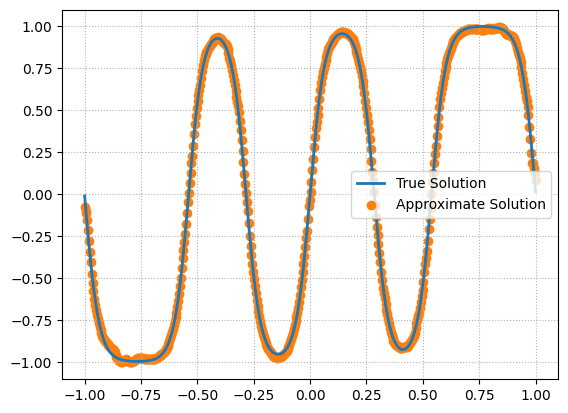

In [128]:
idx_data = 89
input_function_test_n = input_function_test[idx_data].unsqueeze(0)
output_function_test_n = output_function_test[idx_data].unsqueeze(0)
output_function_test_pred_n = model(input_function_test_n)

plt.figure()
plt.grid(True, which="both", ls=":")
X = np.linspace(-1,1,s)
plt.plot(X,output_function_test_n[0,0].detach(), label="True Solution", c="C0", lw=2)
plt.scatter(X,output_function_test_pred_n[0,0].detach(), label="Approximate Solution", c="C1")
p = 1
plt.legend()